In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Disease_symptom_and_patient_profile_dataset.csv to Disease_symptom_and_patient_profile_dataset.csv


In [4]:
df = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")

df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [5]:
print(df.shape)

df.info()

df.describe()

(349, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Disease               349 non-null    object
 1   Fever                 349 non-null    object
 2   Cough                 349 non-null    object
 3   Fatigue               349 non-null    object
 4   Difficulty Breathing  349 non-null    object
 5   Age                   349 non-null    int64 
 6   Gender                349 non-null    object
 7   Blood Pressure        349 non-null    object
 8   Cholesterol Level     349 non-null    object
 9   Outcome Variable      349 non-null    object
dtypes: int64(1), object(9)
memory usage: 27.4+ KB


,Age
count,349.000000
mean,46.323782
std,13.085090
min,19.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,90.000000


In [6]:
df.isnull().sum()

,0
Disease,0
Fever,0
Cough,0
Fatigue,0
Difficulty Breathing,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Outcome Variable,0


In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

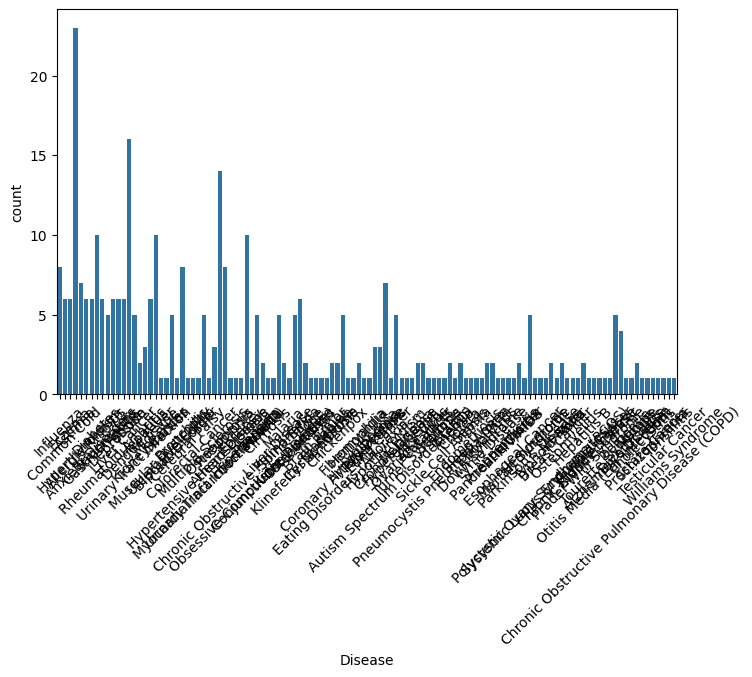

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x='Disease', data=df)

plt.xticks(rotation=45)

plt.show()

In [11]:
encoder = LabelEncoder()

df['Disease'] = encoder.fit_transform(df['Disease'])

In [16]:
X = df.drop('Disease', axis=1)
y = df['Disease']

# Identify categorical columns to encode
categorical_cols = X.select_dtypes(include='object').columns

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy")

print(accuracy_score(y_test, dt_pred))

Decision Tree Accuracy
0.2571428571428571


In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy
0.3


In [21]:
ab = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

print("AdaBoost Accuracy")

print(accuracy_score(y_test, ab_pred))

AdaBoost Accuracy
0.15714285714285714


In [22]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy")

print(accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy
0.24285714285714285


In [23]:
ensemble = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('ab', ab),
        ('gb', gb)
    ],
    voting='hard'
)

ensemble.fit(X_train, y_train)

ensemble_pred = ensemble.predict(X_test)

ensemble_acc = accuracy_score(
    y_test,
    ensemble_pred
)

print("Ensemble Accuracy")

print(ensemble_acc)

Ensemble Accuracy
0.3142857142857143


In [24]:
print(
    classification_report(
        y_test,
        ensemble_pred
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.78      0.78      0.78         9
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.50      0.50      0.50         2
          17       0.00      0.00      0.00         0
          18       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
          22       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         1
          26       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

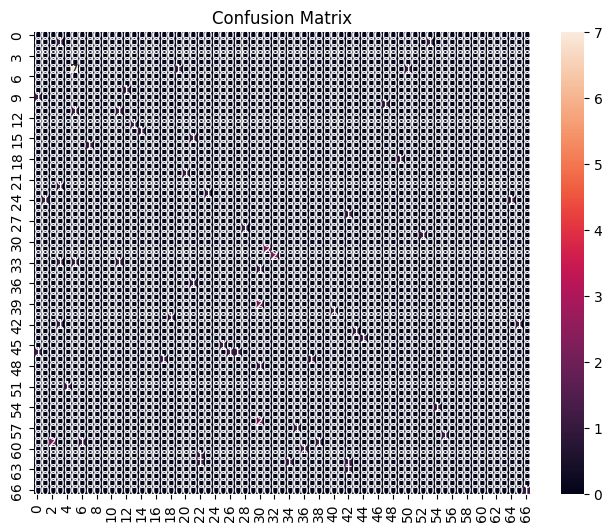

In [25]:
cm = confusion_matrix(
    y_test,
    ensemble_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

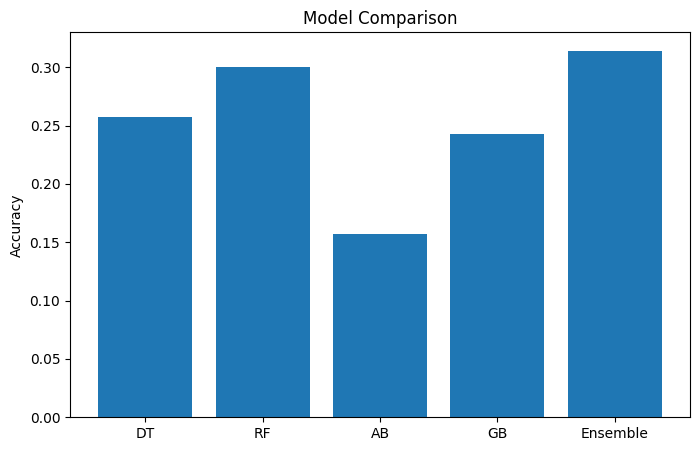

In [26]:
scores = {
    "DT": accuracy_score(y_test, dt_pred),
    "RF": accuracy_score(y_test, rf_pred),
    "AB": accuracy_score(y_test, ab_pred),
    "GB": accuracy_score(y_test, gb_pred),
    "Ensemble": ensemble_acc
}

plt.figure(figsize=(8,5))

plt.bar(scores.keys(), scores.values())

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()